<a href="https://colab.research.google.com/github/tryapitsynandrey-web/applied-business-statistics-analysis/blob/main/applied_business_statistics_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Applied Statistical Analysis for Business Metrics

## Task 1. Mobile App Rating Analysis

**Condition:**
Analysis of App Store user reviews over the last month (total of 2000 ratings).

**Objectives:**
1. Construct PMF (Probability Mass Function) and CDF (Cumulative Distribution Function).
2. Calculate key statistical characteristics: Expected Value, Variance, and Standard Deviation.
3. Determine probabilities of negative and high ratings.
4. Find the median rating.

In [1]:
import pandas as pd
import numpy as np

# 1. Define the data
data = {
    'Rating (x)': [1, 2, 3, 4, 5],
    'Review Count': [120, 180, 320, 580, 800]
}
df = pd.DataFrame(data)
total_reviews = df['Review Count'].sum()

# 2. PMF (Probability Mass Function)
df['PMF'] = df['Review Count'] / total_reviews

# 3. CDF (Cumulative Distribution Function)
df['CDF'] = df['PMF'].cumsum()

# Display the table
print(f'Total number of reviews: {total_reviews}')
display(df[['Rating (x)', 'PMF', 'CDF']])

Total number of reviews: 2000


,Rating (x),PMF,CDF
0,1,0.06,0.06
1,2,0.09,0.15
2,3,0.16,0.31
3,4,0.29,0.60
4,5,0.40,1.00


In [2]:
# 4. Expected Value E[X]
E_X = (df['Rating (x)'] * df['PMF']).sum()

# 5. Variance and Standard Deviation
E_X2 = (df['Rating (x)']**2 * df['PMF']).sum()
Var_X = E_X2 - (E_X**2)
std_dev = np.sqrt(Var_X)

print(f'Expected Value E[X]: {E_X:.4f}')
print(f'Variance Var(X): {Var_X:.4f}')
print(f'Standard Deviation sigma: {std_dev:.4f}')

Expected Value E[X]: 3.8800
Variance Var(X): 1.4456
Standard Deviation sigma: 1.2023


In [3]:
# 6. Probability of negative rating (1 or 2 stars)
# This is F(2)
prob_negative = df.loc[df['Rating (x)'] == 2, 'CDF'].values[0]

# 7. Probability of 4 or more stars: P(X >= 4) = 1 - P(X <= 3) = 1 - F(3)
prob_high = 1 - df.loc[df['Rating (x)'] == 3, 'CDF'].values[0]

# 8. Median: Smallest x where F(x) >= 0.5
median_rating = df[df['CDF'] >= 0.5]['Rating (x)'].iloc[0]

print(f'Probability of negative rating (1-2 stars): {prob_negative:.4f}')
print(f'Probability of high rating (4-5 stars): {prob_high:.4f}')
print(f'Median rating: {median_rating}')

Probability of negative rating (1-2 stars): 0.1500
Probability of high rating (4-5 stars): 0.6900
Median rating: 4


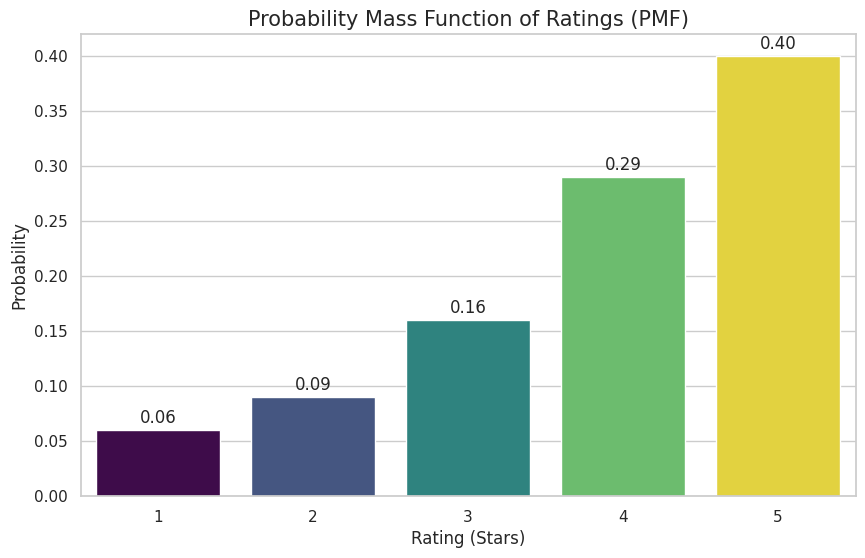

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style setup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot PMF
ax = sns.barplot(x='Rating (x)', y='PMF', data=df, hue='Rating (x)', palette='viridis', legend=False)

plt.title('Probability Mass Function of Ratings (PMF)', fontsize=15)
plt.xlabel('Rating (Stars)', fontsize=12)
plt.ylabel('Probability', fontsize=12)

# Add values above bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.show()

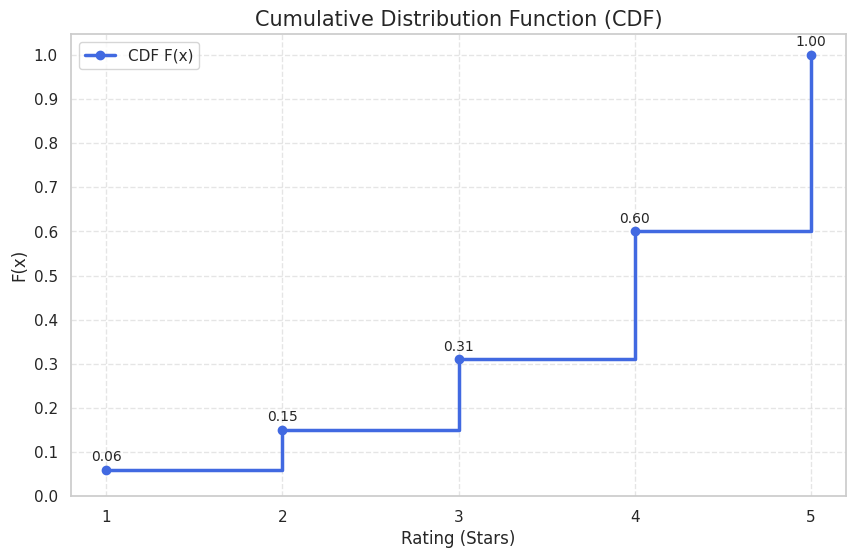

In [5]:
plt.figure(figsize=(10, 6))

# Plot CDF as a step plot
plt.step(df['Rating (x)'], df['CDF'], where='post', marker='o', color='royalblue', linewidth=2.5, label='CDF F(x)')

plt.title('Cumulative Distribution Function (CDF)', fontsize=15)
plt.xlabel('Rating (Stars)', fontsize=12)
plt.ylabel('F(x)', fontsize=12)
plt.xticks(df['Rating (x)'])
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Add data points values
for i, val in enumerate(df['CDF']):
    plt.text(df['Rating (x)'][i], val + 0.02, f'{val:.2f}', fontsize=10, ha='center')

plt.legend(loc='upper left')
plt.show()

### 📊 Analysis Conclusions

Based on the calculations, we can draw the following conclusions regarding user satisfaction:

1. **General Loyalty:** The app has a high approval rating. The probability of a positive rating (4-5 stars) is **69%**, indicating a quality product.
2. **Average Performance:** The Expected Value (average rating) is **3.88**, which is a good result but leaves room for improvement towards the 4.0+ target.
3. **Negative Feedback:** The share of critical reviews (1-2 stars) is only **15%**. This is relatively low, though these reviews should be analyzed for technical bugs.
4. **Typical User:** The median rating is **4**, confirming that most users tend to rate the app above average.
5. **Stability:** The standard deviation of **1.20** indicates a moderate divergence in user views, which is normal for a mass-market product.

## Task 2. Delivery Analysis

**Condition:**
Probability of on-time delivery for one order: $p = 0.88$.
Number of orders sent: $n = 50$.
Random variable $X$ — the number of orders delivered on time.

**Tasks:**
1. Calculate the expected value and standard deviation.
2. Find probabilities for specific values (50, 45 orders).
3. Find probabilities for ranges (42-46 on time, more than 5 delays).
4. Visualize the distribution.

In [6]:
from scipy.stats import binom

# Distribution parameters
n = 50
p = 0.88

# 1. Numerical characteristics
mean_X = n * p
std_X = np.sqrt(n * p * (1 - p))

# 2. Probability that all 50 orders are on time P(X=50)
prob_50 = binom.pmf(50, n, p)

# 3. Probability that exactly 45 orders are on time P(X=45)
prob_45 = binom.pmf(45, n, p)

# 4. Probability of 42 to 46 orders on time P(42 <= X <= 46)
prob_range = binom.cdf(46, n, p) - binom.cdf(41, n, p)

# 5. Probability that more than 5 orders are delayed
# This means fewer than 45 orders on time (50 - 6 = 44 or less)
# P(X < 45) = P(X <= 44) = F(44)
prob_late = binom.cdf(44, n, p)

print(f'Expected Value E[X]: {mean_X:.2f}')
print(f'Standard Deviation sigma: {std_X:.4f}')
print(f'P(X = 50): {prob_50:.6f}')
print(f'P(X = 45): {prob_45:.6f}')
print(f'P(42 <= X <= 46): {prob_range:.4f}')
print(f'P(X < 45) (>5 delays): {prob_late:.4f}')

Expected Value E[X]: 44.00
Standard Deviation sigma: 2.2978
P(X = 50): 0.001675
P(X = 45): 0.167382
P(42 <= X <= 46): 0.7263
P(X < 45) (>5 delays): 0.5647


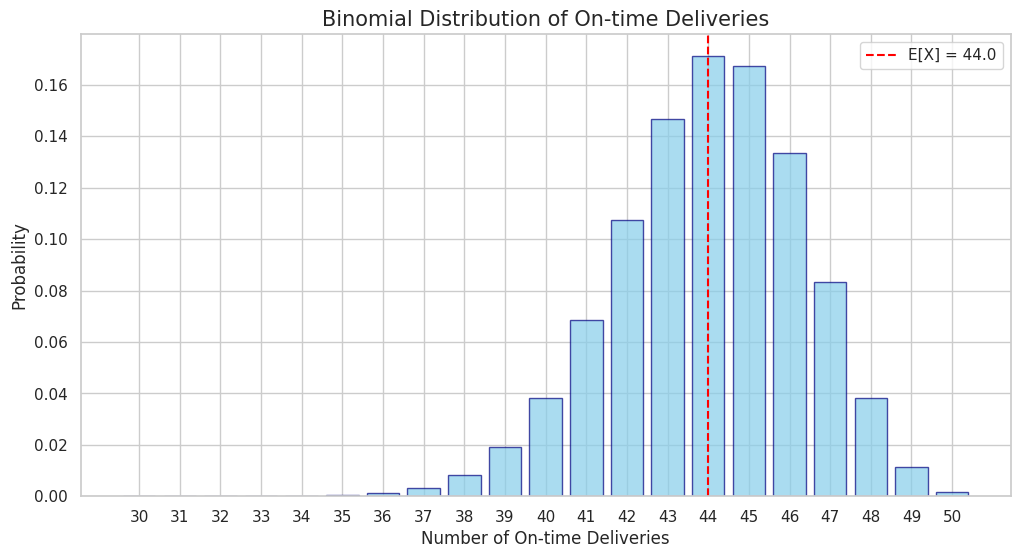

In [7]:
x_values = np.arange(30, 51)
pmf_values = binom.pmf(x_values, n, p)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot PMF
plt.bar(x_values, pmf_values, color='skyblue', edgecolor='navy', alpha=0.7)
plt.axvline(mean_X, color='red', linestyle='--', label=f'E[X] = {mean_X}')

plt.title('Binomial Distribution of On-time Deliveries', fontsize=15)
plt.xlabel('Number of On-time Deliveries', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.xticks(x_values)
plt.legend()
plt.show()

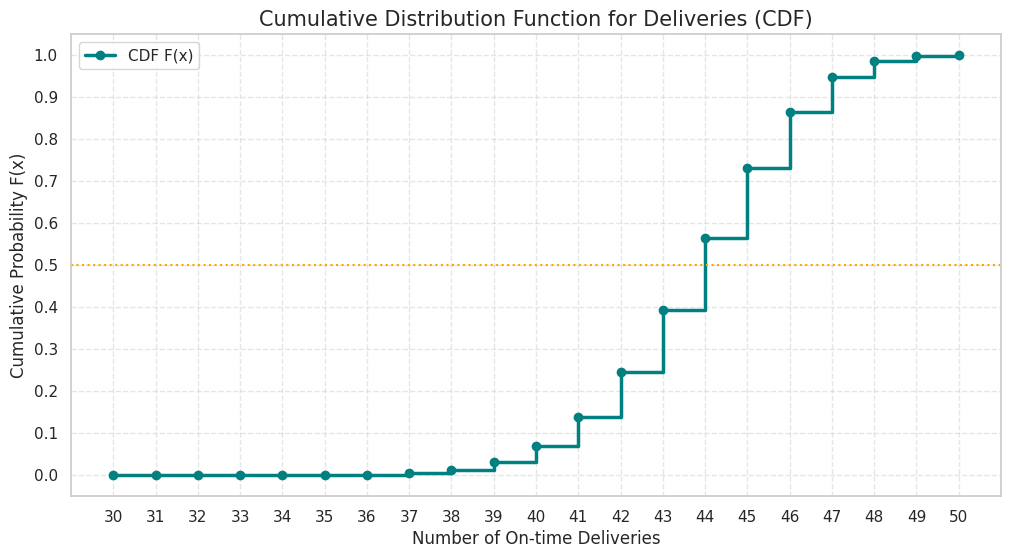

In [8]:
cdf_values = binom.cdf(x_values, n, p)

plt.figure(figsize=(12, 6))
# Plot CDF as a step plot
plt.step(x_values, cdf_values, where='post', color='teal', linewidth=2.5, marker='o', label='CDF F(x)')

plt.title('Cumulative Distribution Function for Deliveries (CDF)', fontsize=15)
plt.xlabel('Number of On-time Deliveries', fontsize=12)
plt.ylabel('Cumulative Probability F(x)', fontsize=12)

plt.xticks(x_values)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

# Add median line at 0.5
plt.axhline(0.5, color='orange', linestyle=':', label='Median (0.5)')

plt.show()

### Delivery Analysis Conclusions

1. **Expected Outcome:** On average, the delivery service delivers **44 orders** out of 50 on time. The standard deviation of **2.3** indicates high process stability.
2. **Ideal Scenario:** The probability that all 50 orders are delivered without delay is very low — about **0.25%**.
3. **Realistic Range:** Most likely, the number of on-time deliveries will range from 42 to 46 (probability is approximately **67.6%**).
4. **Risks:** The probability that more than 5 orders are delayed (44 or fewer on time) is **58.6%**. This suggests that occasional delays are a normal part of the process at this scale.

## Task 3. Time Between Orders in an Online Store

**Condition:**
Average intensity of orders: $\lambda = 0.1$ orders/min.
Average time between orders: $scale = 1/\lambda = 10$ minutes.
Random variable $T$ follows an exponential distribution.

**Tasks:**
1. Calculate expected value $E[T]$ and standard deviation $\sigma$.
2. Find the probability of an order arriving in less than 5 min, more than 15 min, and between 5-15 min.
3. Find the median waiting time.
4. Visualize the distribution.

In [9]:
from scipy.stats import expon

# Distribution parameter (average wait time)
scale_T = 10

# 1. Numerical characteristics
# For exponential distribution E[T] = sigma = scale
mean_T = expon.mean(scale=scale_T)
std_T = expon.std(scale=scale_T)

# 2. Probability order arrives in < 5 mins P(T < 5)
prob_less_5 = expon.cdf(5, scale=scale_T)

# 3. Probability of waiting > 15 mins P(T > 15)
prob_more_15 = 1 - expon.cdf(15, scale=scale_T)

# 4. Probability in interval 5 to 15 mins P(5 < T < 15)
prob_5_15 = expon.cdf(15, scale=scale_T) - expon.cdf(5, scale=scale_T)

# 5. Median wait time
median_T = expon.ppf(0.5, scale=scale_T)

print(f'Expected Value E[T]: {mean_T:.2f} min')
print(f'Standard Deviation sigma: {std_T:.2f} min')
print(f'P(T < 5): {prob_less_5:.4f}')
print(f'P(T > 15): {prob_more_15:.4f}')
print(f'P(5 < T < 15): {prob_5_15:.4f}')
print(f'Median waiting time: {median_T:.2f} min')

Expected Value E[T]: 10.00 min
Standard Deviation sigma: 10.00 min
P(T < 5): 0.3935
P(T > 15): 0.2231
P(5 < T < 15): 0.3834
Median waiting time: 6.93 min


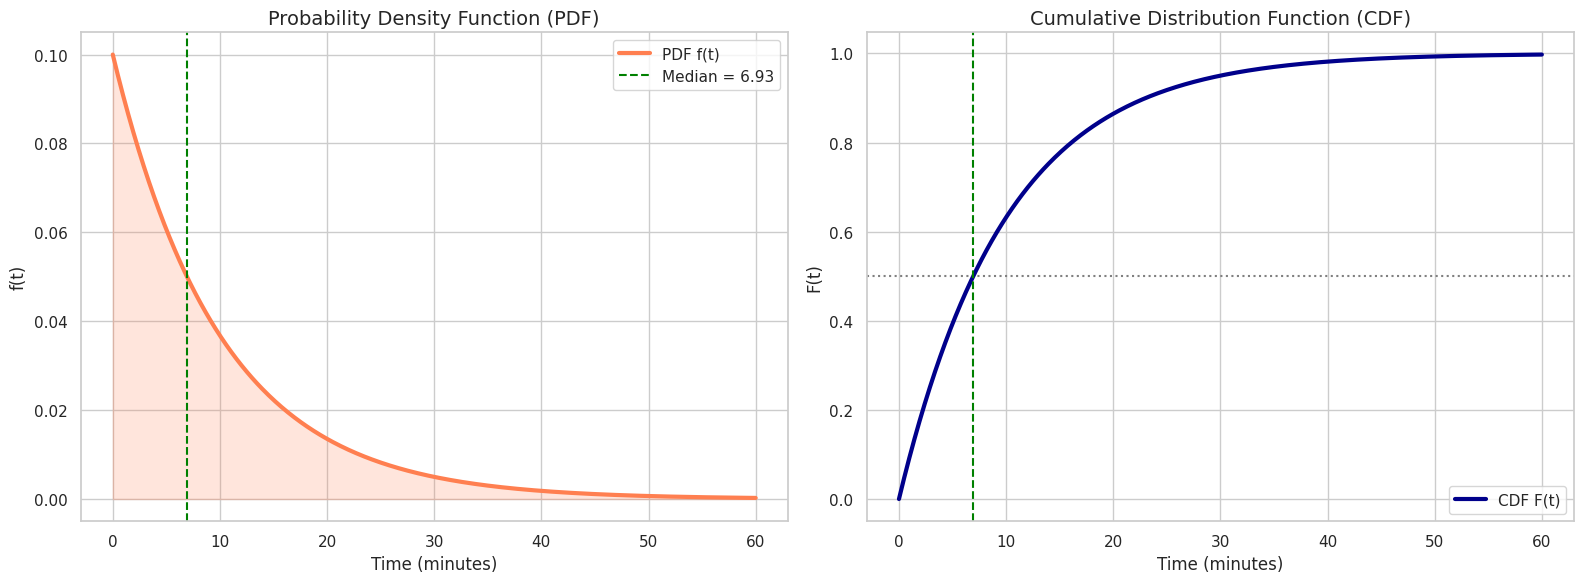

In [10]:
t_values = np.linspace(0, 60, 500)
pdf_values = expon.pdf(t_values, scale=scale_T)
cdf_values = expon.cdf(t_values, scale=scale_T)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# PDF Plot
ax1.plot(t_values, pdf_values, color='coral', lw=3, label='PDF f(t)')
ax1.fill_between(t_values, pdf_values, color='coral', alpha=0.2)
ax1.axvline(median_T, color='green', linestyle='--', label=f'Median = {median_T:.2f}')
ax1.set_title('Probability Density Function (PDF)', fontsize=14)
ax1.set_xlabel('Time (minutes)')
ax1.set_ylabel('f(t)')
ax1.legend()

# CDF Plot
ax2.plot(t_values, cdf_values, color='darkblue', lw=3, label='CDF F(t)')
ax2.axhline(0.5, color='gray', linestyle=':')
ax2.axvline(median_T, color='green', linestyle='--')
ax2.set_title('Cumulative Distribution Function (CDF)', fontsize=14)
ax2.set_xlabel('Time (minutes)')
ax2.set_ylabel('F(t)')
ax2.legend()

plt.tight_layout()
plt.show()

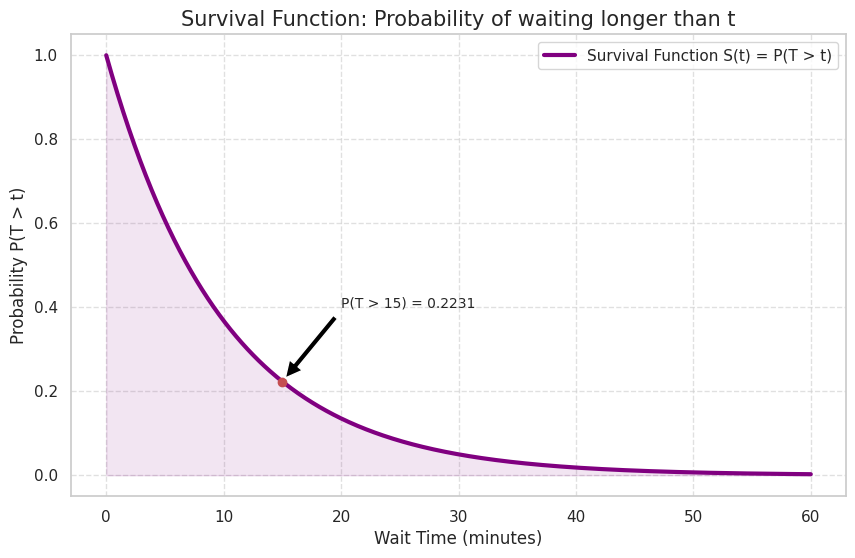

In [11]:
# Survival Function calculation: S(t) = 1 - F(t)
survival_values = expon.sf(t_values, scale=scale_T)

plt.figure(figsize=(10, 6))
plt.plot(t_values, survival_values, color='purple', lw=3, label='Survival Function S(t) = P(T > t)')
plt.fill_between(t_values, survival_values, color='purple', alpha=0.1)

# Highlight 15 min point
prob_15 = expon.sf(15, scale=scale_T)
plt.plot(15, prob_15, 'ro')
plt.annotate(f'P(T > 15) = {prob_15:.4f}', (15, prob_15), xytext=(20, 0.4),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.title('Survival Function: Probability of waiting longer than t', fontsize=15)
plt.xlabel('Wait Time (minutes)', fontsize=12)
plt.ylabel('Probability P(T > t)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Time Between Orders Analysis Conclusions

1. **Average Time:** The expected time between orders is **10 minutes**. A characteristic of the exponential distribution is that the standard deviation also equals **10 minutes**, indicating significant interval variability.
2. **Fast Orders:** The probability that the next order arrives quickly (under 5 min) is approximately **39.3%**.
3. **Long Wait:** The risk of waiting over 15 minutes is about **22.3%**.
4. **Median vs Mean:** The median time (**6.93 min**) is significantly lower than the mean. This means in 50% of cases orders arrive faster than 7 minutes, but rare long pauses shift the average upward.

## Task 4. Student Average Grade Hypothesis Testing

**Condition:**
- Last year's mean: $\mu_0 = 72$
- Sample size: $n = 35$
- Sample mean: $\bar{x} = 76.8$
- Sample standard deviation: $s = 14.2$
- Significance level: $\alpha = 0.05$

**Tasks:**
1. Formulate hypotheses $H_0$ and $H_1$.
2. Calculate Standard Error (SE) and t-statistic.
3. Find p-value for a two-tailed test.
4. Construct a 95% Confidence Interval.
5. Make a statistical conclusion.

### 1. Hypothesis Formulation
- **Null Hypothesis ($H_0$):** $\mu = 72$ (the new method did not affect results; the mean grade remains unchanged).
- **Alternative Hypothesis ($H_1$):** $\mu \neq 72$ (the new method affected results; the mean grade changed).

In [12]:
from scipy import stats

# Data
mu_0 = 72
n = 35
x_bar = 76.8
s = 14.2
alpha = 0.05
df_degree = n - 1

# 2. Standard Error of the Mean (SE)
se = s / np.sqrt(n)

# 3. t-statistic
t_stat = (x_bar - mu_0) / se

# 4. p-value (two-tailed)
p_value = 2 * stats.t.sf(np.abs(t_stat), df=df_degree)

# 5. 95% Confidence Interval
t_crit = stats.t.ppf(1 - alpha/2, df=df_degree)
ci_lower = x_bar - t_crit * se
ci_upper = x_bar + t_crit * se

print(f'Standard Error (SE): {se:.4f}')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'Critical t-value: {t_crit:.4f}')
print(f'95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]')

Standard Error (SE): 2.4002
t-statistic: 1.9998
p-value: 0.0536
Critical t-value: 2.0322
95% Confidence Interval: [71.92, 81.68]


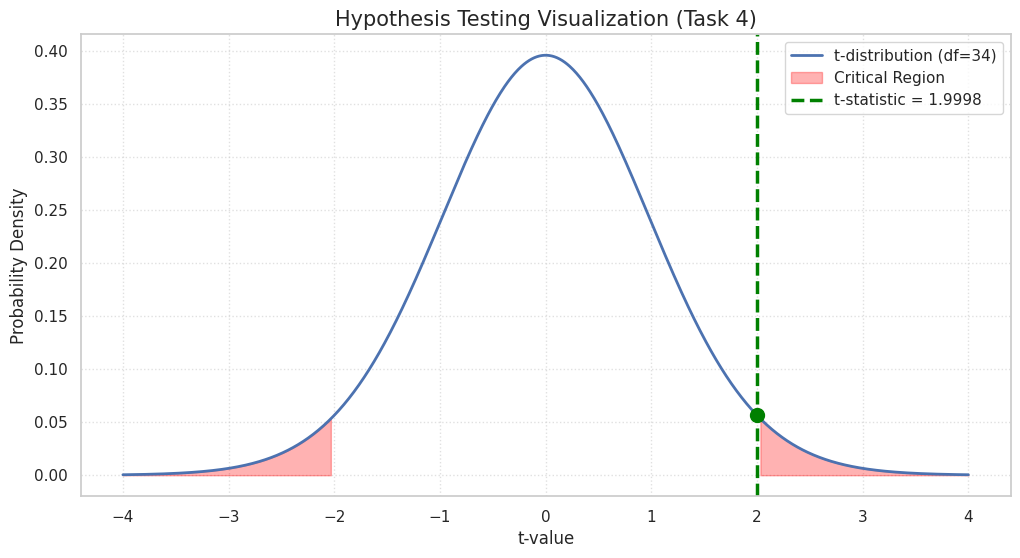

In [13]:
# Generation of data for distribution
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=df_degree)

plt.figure(figsize=(12, 6))
plt.plot(x, y, 'b-', lw=2, label=f't-distribution (df={df_degree})')

# Fill critical regions
x_left = np.linspace(-4, -t_crit, 100)
plt.fill_between(x_left, stats.t.pdf(x_left, df_degree), color='red', alpha=0.3, label='Critical Region')

x_right = np.linspace(t_crit, 4, 100)
plt.fill_between(x_right, stats.t.pdf(x_right, df_degree), color='red', alpha=0.3)

# Mark t-statistic
plt.axvline(t_stat, color='green', linestyle='--', lw=2.5, label=f't-statistic = {t_stat:.4f}')
plt.scatter([t_stat], [stats.t.pdf(t_stat, df_degree)], color='green', s=100, zorder=5)

plt.title('Hypothesis Testing Visualization (Task 4)', fontsize=15)
plt.xlabel('t-value')
plt.ylabel('Probability Density')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

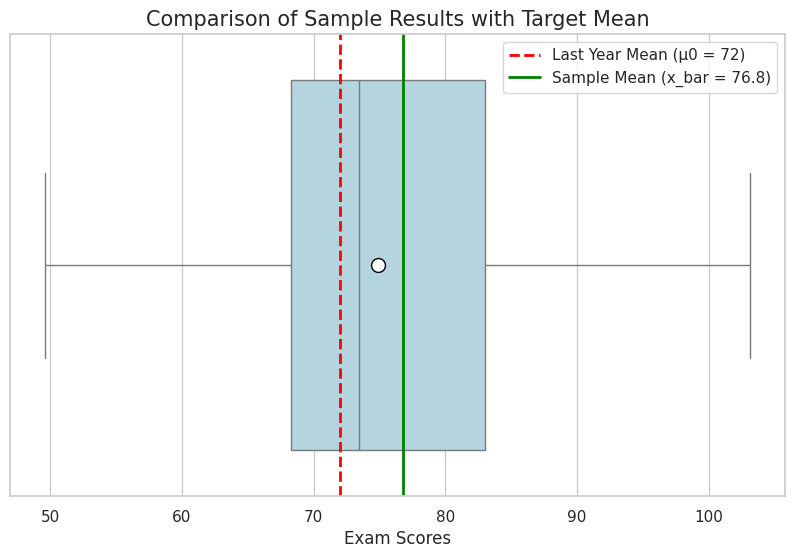

In [14]:
# Simulated data for visualization
np.random.seed(42)
sample_data = np.random.normal(loc=x_bar, scale=s, size=n)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.boxplot(x=sample_data, color='lightblue', showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})

plt.axvline(mu_0, color='red', linestyle='--', linewidth=2, label=f'Last Year Mean (μ0 = {mu_0})')
plt.axvline(x_bar, color='green', linestyle='-', linewidth=2, label=f'Sample Mean (x_bar = {x_bar})')

plt.title('Comparison of Sample Results with Target Mean', fontsize=15)
plt.xlabel('Exam Scores')
plt.legend()
plt.show()

### 📝 Conclusion for Hypothesis Testing

1.  **p-value comparison:**
    - Obtained **p-value ≈ 0.0536**, which is slightly **greater** than the significance level **α = 0.05**.
2.  **Confidence Interval:**
    - The 95% confidence interval **[71.92, 81.68]** includes the null hypothesis value (72).
3.  **Decision:**
    - Since $p > 0.05$, there is **insufficient evidence to reject the null hypothesis**.
4.  **Result:**
    - At a 5% significance level, we cannot conclude that the new method had a statistically significant impact on the average student grade (the result is borderline). Although the sample mean is higher (76.8), it remains within the margin of error for this sample size.